# MNIST Digit Recognition with TensorFlow and Keras

Most code from Deep Learning with Python, Second Edition - François Chollet (2021).

The "OLD VERSION" commented code refers to the (deprecated) version used in the first edition of the book.

In [1]:
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.config import experimental


In [2]:
import utils

In [3]:
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)['mnist']

# frequently used params
width = params['img_width']
height = params['img_height']

utils.print_params(params)

img_width: 28
img_height: 28
layer1_out: 512
learning_rate: 0.001
epochs: 5
batch_size: 128
random_state: 42


In [4]:
# reproducibility
keras.utils.set_random_seed(params['random_state'])
experimental.enable_op_determinism()

## Dataset

### Load

In [5]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [6]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [7]:
set([type(train_images), type(train_labels), type(test_images), type(test_labels)])

{numpy.ndarray}

### Prepare

In [8]:
train_images = train_images.reshape((60000, width * height))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, width * height))
test_images = test_images.astype("float32") / 255

In [9]:
sorted(set(test_labels))

[np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)]

In [10]:
## OLD VERSION (needed)
#from keras.utils import to_categorical
#train_labels = to_categorical(train_labels)
#test_labels = to_categorical(test_labels)

In [11]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 784), (60000,), (10000, 784), (10000,))

## Model

### Build (architecture)

In [12]:
## OLD VERSION (works too)
#from keras import models
#from keras import layers
#
#model = models.Sequential()
#model.add(layers.Dense(params['layer1_out'], activation='relu', input_shape=(width * height,)))
#model.add(layers.Dense(10, activation='softmax'))

In [13]:
model = keras.Sequential([
    layers.Dense(params['layer1_out'], activation="relu"),
    layers.Dense(10, activation="softmax")
])

### Compile

In [14]:
optimizer = optimizers.RMSprop(learning_rate=params['learning_rate'])

In [15]:
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

TODO: WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.

### Training loop (fit)

In [16]:
model.fit(train_images, train_labels, epochs=params['epochs'], batch_size=params['batch_size'])

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9254 - loss: 0.2601
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9695 - loss: 0.1059
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9804 - loss: 0.0687
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9863 - loss: 0.0486
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0350


## Results

### Predictions

In [17]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([5.4225406e-09, 9.9985187e-11, 5.4424191e-07, 8.7059270e-06,
       3.2599245e-14, 1.1699748e-08, 2.2112527e-13, 9.9999046e-01,
       6.6455583e-09, 2.6285562e-07], dtype=float32)

In [18]:
predictions[0].argmax()

np.int64(7)

### Evaluation (accuracy)

In [19]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0779
test_acc: 97.59%


### Show

In [20]:
digit = train_images[4]
digit = digit.reshape(width, height)

In [21]:
## OLD VERSION (fix, for some reason)
#import os
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

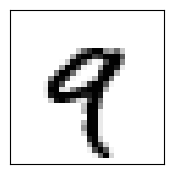

In [22]:
utils.imshow(digit)

Plot wrongly labeled digits in test

In [23]:
import numpy as np

In [24]:
pred = np.argmax(model.predict(test_images), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [25]:
## OLD VERSION
#real = np.argmax(test_labels, axis=1)

real = test_labels.astype(np.int64)

In [26]:
neqs = (pred != real)
neqs = np.where(neqs)[0]
len(neqs)

241

In [27]:
# check accuracy
print(f"{(len(pred) - len(neqs)) / len(pred):.2%}")

97.59%


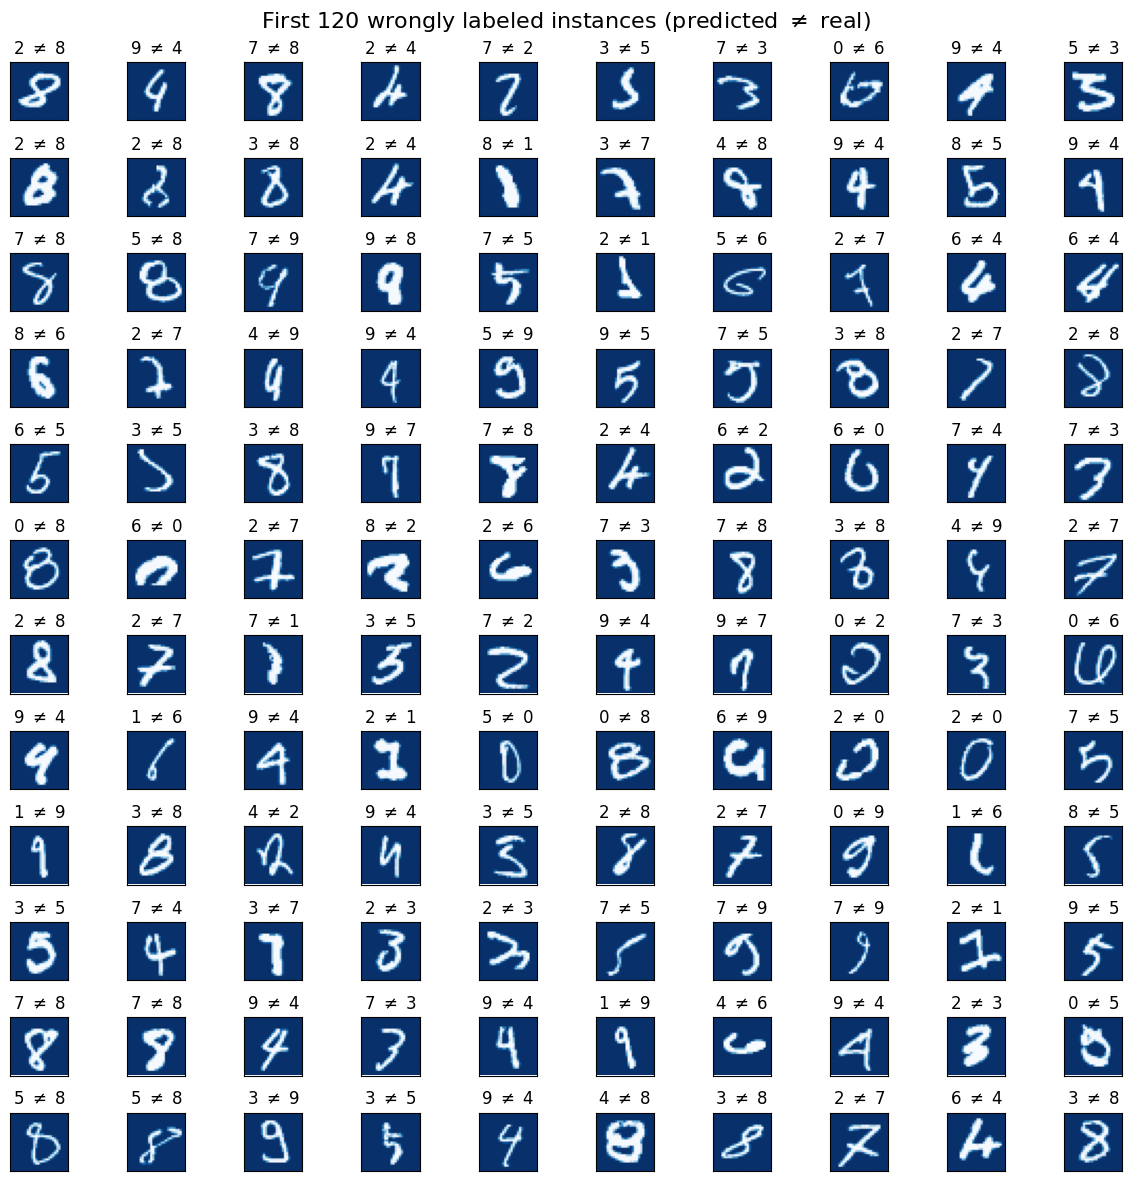

In [28]:
foo = utils.plot_wrong_mnist(test_images, pred, real, neqs, width, height)